# **YOLO 모델 사용**

# 1.환경준비

## (1) 라이브러리 설치

In [1]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 15.8 MB/s eta 0:00:00


## (2) 라이브러리 불러오기

In [2]:
from ultralytics import settings, YOLO
import matplotlib.pyplot as plt
import cv2
import os
from IPython.display import Video

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## (3) YOLO 설정

* 파일 경로 설정

In [3]:
# 현재 세팅을 확인해 봅시다.
settings

{'settings_version': '0.0.6',
 'datasets_dir': '/content/datasets',
 'weights_dir': 'weights',
 'runs_dir': 'runs',
 'uuid': '569f3ba64b326db489132663f79cd37279811de477381b83ac131e6cdd129cbb',
 'sync': True,
 'api_key': '',
 'openai_api_key': '',
 'clearml': True,
 'comet': True,
 'dvc': True,
 'hub': True,
 'mlflow': True,
 'neptune': True,
 'raytune': True,
 'tensorboard': False,
 'wandb': False,
 'vscode_msg': True,
 'openvino_msg': True}

In [4]:
# 콜랩 파일 탭에 보이는 경로('/content/')로 변경해 봅시다.
settings['datasets_dir'] = '/content/'
settings.update()
settings

{'settings_version': '0.0.6',
 'datasets_dir': '/content/',
 'weights_dir': 'weights',
 'runs_dir': 'runs',
 'uuid': '569f3ba64b326db489132663f79cd37279811de477381b83ac131e6cdd129cbb',
 'sync': True,
 'api_key': '',
 'openai_api_key': '',
 'clearml': True,
 'comet': True,
 'dvc': True,
 'hub': True,
 'mlflow': True,
 'neptune': True,
 'raytune': True,
 'tensorboard': False,
 'wandb': False,
 'vscode_msg': True,
 'openvino_msg': True}

# 2.모델 사용

## (1) 모델 다운로드

- 모델의 구조와 해당 구조에 맞게 사전 학습된 가중치를 불러온다.
- Parameters
    * model : 모델 구조 또는 모델 구조 + 가중치 설정. task와 맞는 모델을 선택해야 한다.
    * task : detect, segment, classify, pose 중 택일

In [5]:
model = YOLO(model='yolo11n.pt', task='detect')

## (2) 모델 사용 : 이미지

아래 이미지에 대해서 객체 탐지를 해 봅시다.

![이미지](https://images.pexels.com/photos/139303/pexels-photo-139303.jpeg)


In [6]:
image_path = 'https://images.pexels.com/photos/139303/pexels-photo-139303.jpeg'
results = model.predict(image_path, save=True)
results[0].show()  # 탐지된 객체 출력

Output hidden; open in https://colab.research.google.com to view.

## (3)실습
* 다양한 사진을 찾아서 object detection 해 봅시다.

100%|██████████| 190k/190k [00:00<00:00, 545kB/s]


image 1/1 /content/2018011700908_0.jpg: 320x640 4 cats, 5 dogs, 366.6ms
Speed: 30.9ms preprocess, 366.6ms inference, 39.6ms postprocess per image at shape (1, 3, 320, 640)
Results saved to runs/detect/predict


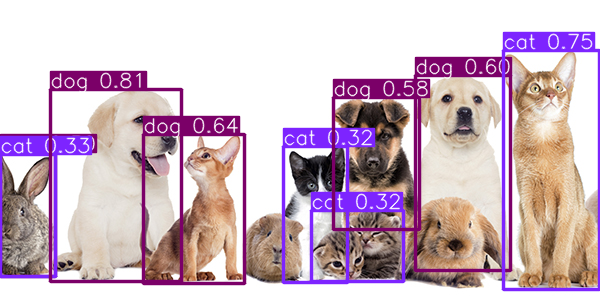

In [ ]:
image_path = 'https://health.chosun.com/site/data/img_dir/2018/01/17/2018011700908_0.jpg'
results = model.predict(image_path, save=True)
results[0].show()  # 탐지된 객체 출력

## (4) 객체탐지 결과 열어보기

In [ ]:
results

In [ ]:
print(type(results))
print(len(results))

<class 'list'>
1


In [ ]:
type(results[0])

ultralytics.engine.results.Results

In [ ]:
results[0]

In [ ]:
results[0].names

In [ ]:
results[0].boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([16., 15., 16., 16., 16., 15., 15., 15., 16.])
conf: tensor([0.8070, 0.7510, 0.6414, 0.6031, 0.5771, 0.3304, 0.3218, 0.3171, 0.2993])
data: tensor([[5.0321e+01, 8.9081e+01, 1.8148e+02, 2.8155e+02, 8.0700e-01, 1.6000e+01],
        [5.0334e+02, 5.0225e+01, 5.9957e+02, 2.8975e+02, 7.5101e-01, 1.5000e+01],
        [1.4331e+02, 1.3434e+02, 2.4416e+02, 2.8326e+02, 6.4143e-01, 1.6000e+01],
        [4.1532e+02, 7.5639e+01, 5.1083e+02, 2.7076e+02, 6.0312e-01, 1.6000e+01],
        [3.3347e+02, 9.7799e+01, 4.1919e+02, 2.2990e+02, 5.7714e-01, 1.6000e+01],
        [2.4827e-01, 1.5401e+02, 5.5766e+01, 2.7624e+02, 3.3044e-01, 1.5000e+01],
        [2.8332e+02, 1.4609e+02, 3.4703e+02, 2.8275e+02, 3.2178e-01, 1.5000e+01],
        [3.1169e+02, 2.1042e+02, 4.0371e+02, 2.8150e+02, 3.1713e-01, 1.5000e+01],
        [5.7217e-02, 1.5225e+02, 5.5613e+01, 2.7632e+02, 2.9930e-01, 1.6000e+01]])
id: None
is_track: False
orig_shape: (299, 600)
sha

In [ ]:
for box in results[0].boxes:
    x_min, y_min, x_max, y_max = box.xyxy[0]  # 좌표
    conf = box.conf[0]
    cn = results[0].names[int(box.cls[0])]  # 클래스 이름
    print(f"좌표: {x_min}, {y_min}, {x_max}, {y_max} | conf. : {conf} | class : {cn}")

좌표: 50.321258544921875, 89.08125305175781, 181.48129272460938, 281.5506286621094 | conf. : 0.8069987893104553 | class : dog
좌표: 503.3432312011719, 50.224910736083984, 599.5650634765625, 289.749755859375 | conf. : 0.751011312007904 | class : cat
좌표: 143.3121795654297, 134.34230041503906, 244.15960693359375, 283.25830078125 | conf. : 0.6414327025413513 | class : dog
좌표: 415.3197326660156, 75.63863372802734, 510.8250427246094, 270.7585144042969 | conf. : 0.6031150817871094 | class : dog
좌표: 333.4677734375, 97.79879760742188, 419.1873474121094, 229.90184020996094 | conf. : 0.5771416425704956 | class : dog
좌표: 0.24826525151729584, 154.00579833984375, 55.76631164550781, 276.2401428222656 | conf. : 0.3304426968097687 | class : cat
좌표: 283.3240661621094, 146.0870361328125, 347.0337829589844, 282.7503967285156 | conf. : 0.32178249955177307 | class : cat
좌표: 311.6914978027344, 210.41879272460938, 403.7074890136719, 281.5046691894531 | conf. : 0.31713104248046875 | class : cat
좌표: 0.0572168789803

## (5) 모델사용 : 동영상

* sample.mp4 파일을 업로드 합니다.

In [7]:
# colab 파일 업로드
from google.colab import files
uploaded = files.upload()

Saving sample.mp4 to sample.mp4


* 동영상 객체 탐지 실행

In [8]:
# 동영상 객체 탐지 실행 및 결과 저장
results = model.predict("sample.mp4", save=True)  # 결과 자동 저장


WARNING ⚠️ 
inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/210) /content/sample.mp4: 416x640 2 cats, 170.9ms
video 1/1 (frame 2/210) /content/sample.mp4: 416x640 2 cats, 155.0ms
video 1/1 (frame 3/210) /content/sample.mp4: 416x640 2 cats, 146.6ms
video 1/1 (frame 4/210) /content/sample.mp4: 416x640 2 cats, 1 dog, 148.2ms
video 1/1 (frame 5/210) /content/sample.mp4: 416x640 2 cats, 1 dog, 150.8ms
video 1/1 (frame 6/210) /content/sample.mp4: 416x640 2 cats, 147.3ms
video 1/1 (frame 7/210) /con

In [9]:
# 탐지된 동영상 결과 경로 확인
os.listdir("runs/detect/predict/")

['pexels-photo-139303.jpg', 'sample.avi']

* 콜랩에서 영상 play를 위한 세팅

In [10]:
# 영상 코덱 설치
!apt-get install -y ffmpeg

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.


In [11]:
# AVI to MP4로 변환 (YOLO 탐지 결과 파일명에 맞게 수정)
input_video_path = "runs/detect/predict/sample.avi"  # YOLO 탐지 결과 파일명
output_video_path = "runs/detect/predict/video_converted.mp4"

# FFmpeg를 사용하여 변환 (코덱: libx264)
!ffmpeg -i {input_video_path} -vcodec libx264 {output_video_path}

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

* 영상 paly

In [12]:
# YOLO 탐지 결과 동영상 재생
Video("runs/detect/predict/video_converted.mp4", embed=True)

# 3.Confidence Score, IoU

## (1) 이미지 탐지 : default


Found https://health.chosun.com/site/data/img_dir/2018/01/17/2018011700908_0.jpg locally at 2018011700908_0.jpg
image 1/1 /content/2018011700908_0.jpg: 320x640 3 cats, 4 dogs, 137.4ms
Speed: 3.4ms preprocess, 137.4ms inference, 1.8ms postprocess per image at shape (1, 3, 320, 640)
Results saved to runs/detect/predict


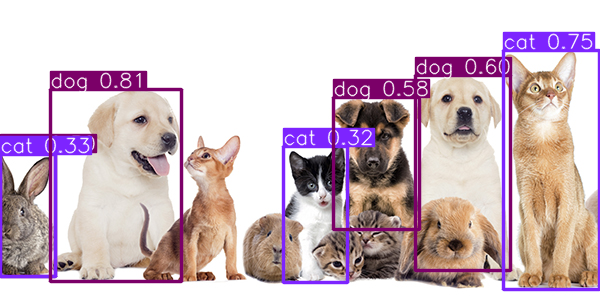

In [ ]:
# 기본 설정(conf=0.25, iou=0.45)
image_path = 'https://health.chosun.com/site/data/img_dir/2018/01/17/2018011700908_0.jpg'
results = model.predict(image_path, save=True)
results[0].show()  # 탐지된 객체 출력

## (2) Confidence 값 조정

In [ ]:
high_conf = model(image_path, conf=0.7)  # 신뢰도 증가
low_conf = model(image_path, conf=0.1)   # 신뢰도 감소


Found https://health.chosun.com/site/data/img_dir/2018/01/17/2018011700908_0.jpg locally at 2018011700908_0.jpg
image 1/1 /content/2018011700908_0.jpg: 320x640 1 cat, 1 dog, 120.9ms
Speed: 2.7ms preprocess, 120.9ms inference, 1.1ms postprocess per image at shape (1, 3, 320, 640)

Found https://health.chosun.com/site/data/img_dir/2018/01/17/2018011700908_0.jpg locally at 2018011700908_0.jpg
image 1/1 /content/2018011700908_0.jpg: 320x640 5 cats, 4 dogs, 125.3ms
Speed: 3.7ms preprocess, 125.3ms inference, 1.2ms postprocess per image at shape (1, 3, 320, 640)


* 탐색 결과

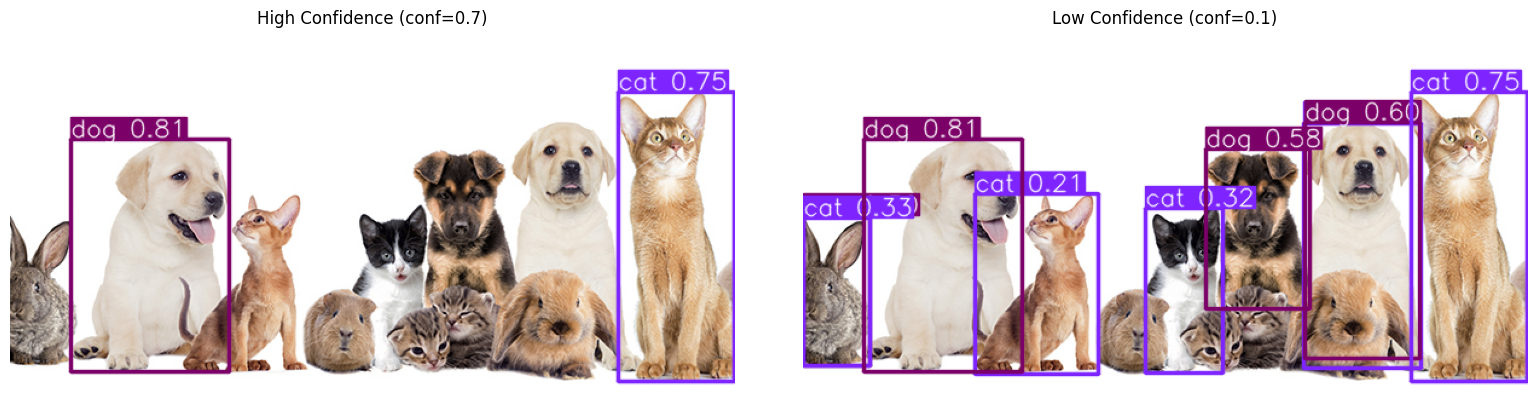

In [ ]:
# Matplotlib 서브플롯 설정
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# 결과를 NumPy 배열로 변환하여 Matplotlib에 표시 (BGR → RGB 변환 포함)
axes[0].imshow(cv2.cvtColor(high_conf[0].plot(), cv2.COLOR_BGR2RGB))  # 높은 신뢰도
axes[0].set_title("High Confidence (conf=0.7)")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(low_conf[0].plot(), cv2.COLOR_BGR2RGB))  # 낮은 신뢰도
axes[1].set_title("Low Confidence (conf=0.1)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## (3) IoU 임계 값 조정

In [ ]:
high_iou = model(image_path, iou=0.7)   # IoU 증가
low_iou = model(image_path, iou=0.01)    # IoU 감소


Found https://health.chosun.com/site/data/img_dir/2018/01/17/2018011700908_0.jpg locally at 2018011700908_0.jpg
image 1/1 /content/2018011700908_0.jpg: 320x640 4 cats, 5 dogs, 120.7ms
Speed: 2.8ms preprocess, 120.7ms inference, 1.3ms postprocess per image at shape (1, 3, 320, 640)

Found https://health.chosun.com/site/data/img_dir/2018/01/17/2018011700908_0.jpg locally at 2018011700908_0.jpg
image 1/1 /content/2018011700908_0.jpg: 320x640 3 cats, 2 dogs, 125.0ms
Speed: 2.2ms preprocess, 125.0ms inference, 1.8ms postprocess per image at shape (1, 3, 320, 640)


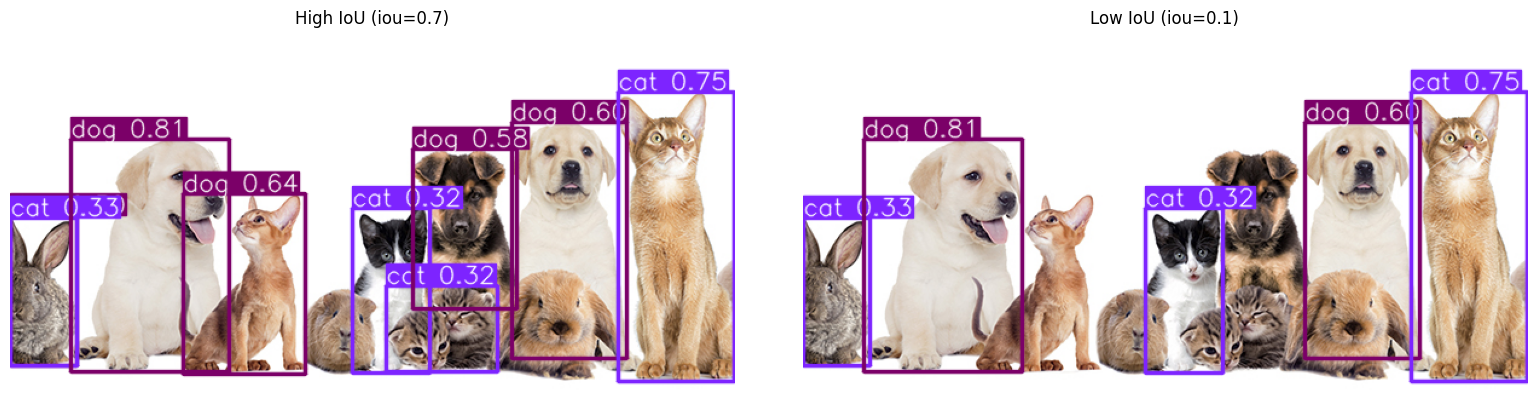

In [ ]:
# Matplotlib 서브플롯 설정
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# 결과를 NumPy 배열로 변환하여 Matplotlib에 표시 (BGR → RGB 변환 포함)
axes[0].imshow(cv2.cvtColor(high_iou[0].plot(), cv2.COLOR_BGR2RGB))  # 높은 IoU
axes[0].set_title("High IoU (iou=0.7)")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(low_iou[0].plot(), cv2.COLOR_BGR2RGB))  # 낮은 IoU
axes[1].set_title("Low IoU (iou=0.1)")
axes[1].axis("off")

plt.tight_layout()
plt.show()